In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("train.csv")
df.head()

,timestamp,active_power_calculated_by_converter,active_power_raw,ambient_temperature,generator_speed,generator_winding_temp_max,grid_power10min_average,nc1_inside_temp,nacelle_temp,reactice_power_calculated_by_converter,reactive_power,wind_direction_raw,wind_speed_raw,wind_speed_turbulence,turbine_id,Target
0,2021-02-19 20:18:00,816.636759,834.917206,31.694380,1159.616602,65.954214,917.897085,31.881972,31.504713,141.457644,165.501518,280.864782,7.057000,0.544082,Turbine_108,47.582787
1,2021-04-27 04:55:00,419.107829,421.050873,12.894948,928.747996,59.571319,445.554250,32.423705,32.755770,89.186457,113.835236,299.552460,5.474937,0.469031,Turbine_18,46.070328
2,2021-01-25 06:26:00,1303.530558,1337.566142,16.648388,1201.219775,61.270498,1364.716003,11.446849,18.332985,230.622309,281.452253,84.960106,8.092457,0.622318,Turbine_105,39.989236
3,2021-10-30 03:47:00,61.494872,53.481008,28.388141,769.806122,40.674348,14.324897,34.253204,32.662889,66.211015,75.017531,87.261119,4.071032,0.760719,Turbine_15,46.056587
4,2021-03-15 00:39:00,593.514364,611.659108,31.519527,1046.916768,64.341763,599.020172,32.405586,31.466387,137.163938,160.202421,313.724818,6.357943,0.346068,Turbine_01,54.346095


In [3]:
#EDA
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 909604 entries, 0 to 909603
Data columns (total 16 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   timestamp                               909604 non-null  object 
 1   active_power_calculated_by_converter    909604 non-null  float64
 2   active_power_raw                        909604 non-null  float64
 3   ambient_temperature                     909604 non-null  float64
 4   generator_speed                         909604 non-null  float64
 5   generator_winding_temp_max              909604 non-null  float64
 6   grid_power10min_average                 909604 non-null  float64
 7   nc1_inside_temp                         909604 non-null  float64
 8   nacelle_temp                            909604 non-null  float64
 9   reactice_power_calculated_by_converter  909604 non-null  float64
 10  reactive_power                          9096

In [4]:
df.isnull().sum()

timestamp                                 0
active_power_calculated_by_converter      0
active_power_raw                          0
ambient_temperature                       0
generator_speed                           0
generator_winding_temp_max                0
grid_power10min_average                   0
nc1_inside_temp                           0
nacelle_temp                              0
reactice_power_calculated_by_converter    0
reactive_power                            0
wind_direction_raw                        0
wind_speed_raw                            0
wind_speed_turbulence                     0
turbine_id                                0
Target                                    0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.head()

,timestamp,active_power_calculated_by_converter,active_power_raw,ambient_temperature,generator_speed,generator_winding_temp_max,grid_power10min_average,nc1_inside_temp,nacelle_temp,reactice_power_calculated_by_converter,reactive_power,wind_direction_raw,wind_speed_raw,wind_speed_turbulence,turbine_id,Target
0,2021-02-19 20:18:00,816.636759,834.917206,31.694380,1159.616602,65.954214,917.897085,31.881972,31.504713,141.457644,165.501518,280.864782,7.057000,0.544082,Turbine_108,47.582787
1,2021-04-27 04:55:00,419.107829,421.050873,12.894948,928.747996,59.571319,445.554250,32.423705,32.755770,89.186457,113.835236,299.552460,5.474937,0.469031,Turbine_18,46.070328
2,2021-01-25 06:26:00,1303.530558,1337.566142,16.648388,1201.219775,61.270498,1364.716003,11.446849,18.332985,230.622309,281.452253,84.960106,8.092457,0.622318,Turbine_105,39.989236
3,2021-10-30 03:47:00,61.494872,53.481008,28.388141,769.806122,40.674348,14.324897,34.253204,32.662889,66.211015,75.017531,87.261119,4.071032,0.760719,Turbine_15,46.056587
4,2021-03-15 00:39:00,593.514364,611.659108,31.519527,1046.916768,64.341763,599.020172,32.405586,31.466387,137.163938,160.202421,313.724818,6.357943,0.346068,Turbine_01,54.346095


In [7]:
df.tail()

,timestamp,active_power_calculated_by_converter,active_power_raw,ambient_temperature,generator_speed,generator_winding_temp_max,grid_power10min_average,nc1_inside_temp,nacelle_temp,reactice_power_calculated_by_converter,reactive_power,wind_direction_raw,wind_speed_raw,wind_speed_turbulence,turbine_id,Target
909599,2021-04-25 19:12:00,929.101908,948.441905,32.736076,1187.303192,83.187140,1343.320577,32.291391,35.152280,152.216446,191.088800,189.901812,7.155343,1.028960,Turbine_13,50.768675
909600,2021-02-20 17:37:00,100.730526,88.694599,30.540500,770.245593,56.235497,177.620552,30.434302,29.932141,85.353107,96.621675,93.417590,4.121607,0.595874,Turbine_158,44.234821
909601,2021-10-22 14:18:00,1120.915965,1165.016907,30.901129,1170.456860,62.942943,873.414622,30.491818,33.085164,42.820210,74.111173,230.988398,8.551669,0.951241,Turbine_15,46.942486
909602,2021-02-08 22:03:00,123.444564,116.066919,32.697933,770.190796,57.245207,95.865704,32.338824,31.525384,86.549094,97.470984,65.408801,4.324064,0.247335,Turbine_97,46.392221
909603,2021-04-09 14:28:00,4.843147,10.779734,19.452520,736.601664,60.603885,78.559767,30.798932,38.252200,2.763231,1.320198,11.127739,2.017444,0.963029,Turbine_105,48.902180


In [8]:
df['timestamp'] = pd.to_datetime(df['timestamp'],errors = 'coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 909604 entries, 0 to 909603
Data columns (total 16 columns):
 #   Column                                  Non-Null Count   Dtype         
---  ------                                  --------------   -----         
 0   timestamp                               909604 non-null  datetime64[ns]
 1   active_power_calculated_by_converter    909604 non-null  float64       
 2   active_power_raw                        909604 non-null  float64       
 3   ambient_temperature                     909604 non-null  float64       
 4   generator_speed                         909604 non-null  float64       
 5   generator_winding_temp_max              909604 non-null  float64       
 6   grid_power10min_average                 909604 non-null  float64       
 7   nc1_inside_temp                         909604 non-null  float64       
 8   nacelle_temp                            909604 non-null  float64       
 9   reactice_power_calculated_by_converte

In [9]:
df.head()

,timestamp,active_power_calculated_by_converter,active_power_raw,ambient_temperature,generator_speed,generator_winding_temp_max,grid_power10min_average,nc1_inside_temp,nacelle_temp,reactice_power_calculated_by_converter,reactive_power,wind_direction_raw,wind_speed_raw,wind_speed_turbulence,turbine_id,Target
0,2021-02-19 20:18:00,816.636759,834.917206,31.694380,1159.616602,65.954214,917.897085,31.881972,31.504713,141.457644,165.501518,280.864782,7.057000,0.544082,Turbine_108,47.582787
1,2021-04-27 04:55:00,419.107829,421.050873,12.894948,928.747996,59.571319,445.554250,32.423705,32.755770,89.186457,113.835236,299.552460,5.474937,0.469031,Turbine_18,46.070328
2,2021-01-25 06:26:00,1303.530558,1337.566142,16.648388,1201.219775,61.270498,1364.716003,11.446849,18.332985,230.622309,281.452253,84.960106,8.092457,0.622318,Turbine_105,39.989236
3,2021-10-30 03:47:00,61.494872,53.481008,28.388141,769.806122,40.674348,14.324897,34.253204,32.662889,66.211015,75.017531,87.261119,4.071032,0.760719,Turbine_15,46.056587
4,2021-03-15 00:39:00,593.514364,611.659108,31.519527,1046.916768,64.341763,599.020172,32.405586,31.466387,137.163938,160.202421,313.724818,6.357943,0.346068,Turbine_01,54.346095


In [10]:
#heatmap
cor_mat = df.corr(numeric_only = True)
print(cor_mat)

                                        active_power_calculated_by_converter  \
active_power_calculated_by_converter                                1.000000   
active_power_raw                                                    0.996435   
ambient_temperature                                                -0.055748   
generator_speed                                                     0.865399   
generator_winding_temp_max                                          0.704785   
grid_power10min_average                                             0.951129   
nc1_inside_temp                                                    -0.048977   
nacelle_temp                                                       -0.114523   
reactice_power_calculated_by_converter                              0.859807   
reactive_power                                                      0.890428   
wind_direction_raw                                                  0.047813   
wind_speed_raw                          

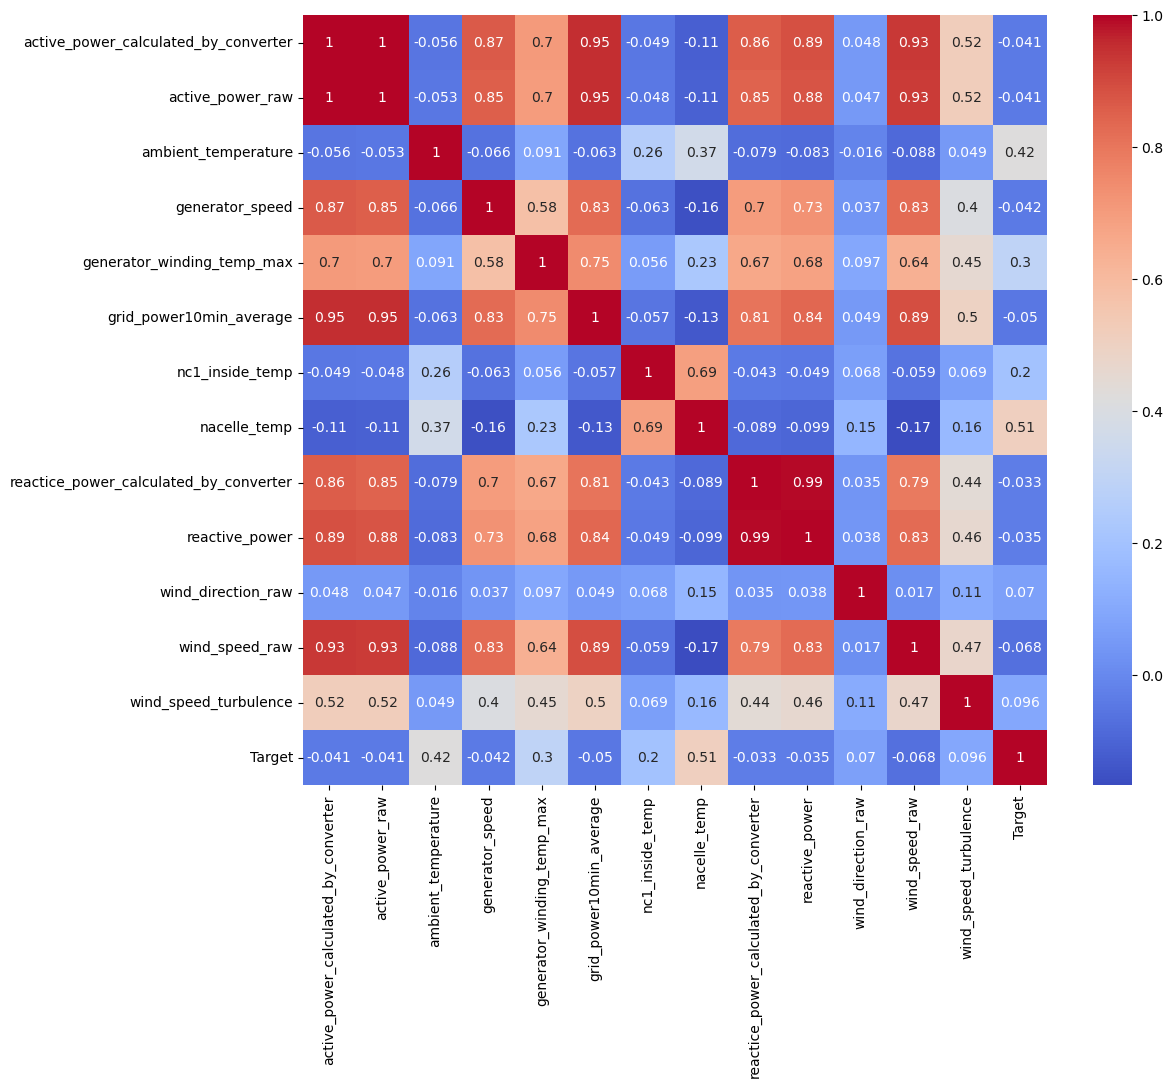

In [13]:
plt.figure(figsize = (12,10))
sns.heatmap(cor_mat,annot=True, cmap="coolwarm")
plt.show()

In [19]:
#VIF and remove the target column from the calculation
from statsmodels.stats.outliers_influence import variance_inflation_factor

col_list = []
for i in df.columns:
    if (df[i].dtype == 'float64') & (i != 'Target'):
        col_list.append(i)
x = df[col_list]
vif_data = pd.DataFrame()
vif_data['Column Names'] = x.columns
#VIF values should be passed via an array to the DF
vif_data['VIF Score'] = [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]

In [22]:
vif_data.sort_values(by = 'VIF Score', ascending = False)

,Column Names,VIF Score
9,reactive_power,427.087748
0,active_power_calculated_by_converter,398.566300
1,active_power_raw,361.707774
8,reactice_power_calculated_by_converter,328.529943
7,nacelle_temp,255.939425
6,nc1_inside_temp,140.004469
4,generator_winding_temp_max,127.768808
3,generator_speed,75.538793
11,wind_speed_raw,74.328616
5,grid_power10min_average,30.870003


In [23]:
df = df.drop(columns = ['reactive_power'])
df.head()

,timestamp,active_power_calculated_by_converter,active_power_raw,ambient_temperature,generator_speed,generator_winding_temp_max,grid_power10min_average,nc1_inside_temp,nacelle_temp,reactice_power_calculated_by_converter,wind_direction_raw,wind_speed_raw,wind_speed_turbulence,turbine_id,Target
0,2021-02-19 20:18:00,816.636759,834.917206,31.694380,1159.616602,65.954214,917.897085,31.881972,31.504713,141.457644,280.864782,7.057000,0.544082,Turbine_108,47.582787
1,2021-04-27 04:55:00,419.107829,421.050873,12.894948,928.747996,59.571319,445.554250,32.423705,32.755770,89.186457,299.552460,5.474937,0.469031,Turbine_18,46.070328
2,2021-01-25 06:26:00,1303.530558,1337.566142,16.648388,1201.219775,61.270498,1364.716003,11.446849,18.332985,230.622309,84.960106,8.092457,0.622318,Turbine_105,39.989236
3,2021-10-30 03:47:00,61.494872,53.481008,28.388141,769.806122,40.674348,14.324897,34.253204,32.662889,66.211015,87.261119,4.071032,0.760719,Turbine_15,46.056587
4,2021-03-15 00:39:00,593.514364,611.659108,31.519527,1046.916768,64.341763,599.020172,32.405586,31.466387,137.163938,313.724818,6.357943,0.346068,Turbine_01,54.346095


In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

col_list = []
for i in df.columns:
    if (df[i].dtype == 'float64') & (i != 'Target'):
        col_list.append(i)
x = df[col_list]
vif_data = pd.DataFrame()
vif_data['Column Names'] = x.columns
#VIF values should be passed via an array to the DF
vif_data['VIF Score'] = [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]

In [25]:
vif_data

,Column Names,VIF Score
0,active_power_calculated_by_converter,395.268258
1,active_power_raw,350.365548
2,ambient_temperature,13.104176
3,generator_speed,74.194993
4,generator_winding_temp_max,127.029415
5,grid_power10min_average,30.867511
6,nc1_inside_temp,140.004381
7,nacelle_temp,255.874458
8,reactice_power_calculated_by_converter,13.312498
9,wind_direction_raw,4.821565


In [26]:
df = df.drop(columns = ['active_power_calculated_by_converter'])
df.head()

,timestamp,active_power_raw,ambient_temperature,generator_speed,generator_winding_temp_max,grid_power10min_average,nc1_inside_temp,nacelle_temp,reactice_power_calculated_by_converter,wind_direction_raw,wind_speed_raw,wind_speed_turbulence,turbine_id,Target
0,2021-02-19 20:18:00,834.917206,31.694380,1159.616602,65.954214,917.897085,31.881972,31.504713,141.457644,280.864782,7.057000,0.544082,Turbine_108,47.582787
1,2021-04-27 04:55:00,421.050873,12.894948,928.747996,59.571319,445.554250,32.423705,32.755770,89.186457,299.552460,5.474937,0.469031,Turbine_18,46.070328
2,2021-01-25 06:26:00,1337.566142,16.648388,1201.219775,61.270498,1364.716003,11.446849,18.332985,230.622309,84.960106,8.092457,0.622318,Turbine_105,39.989236
3,2021-10-30 03:47:00,53.481008,28.388141,769.806122,40.674348,14.324897,34.253204,32.662889,66.211015,87.261119,4.071032,0.760719,Turbine_15,46.056587
4,2021-03-15 00:39:00,611.659108,31.519527,1046.916768,64.341763,599.020172,32.405586,31.466387,137.163938,313.724818,6.357943,0.346068,Turbine_01,54.346095


In [28]:
col_list = []
for i in df.columns:
    if (df[i].dtype == 'float64') & (i != 'Target'):
        col_list.append(i)
x = df[col_list]
vif_data = pd.DataFrame()
vif_data['Column Names'] = x.columns
#VIF values should be passed via an array to the DF
vif_data['VIF Score'] = [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
vif_data.sort_values(by = 'VIF Score', ascending = False)

,Column Names,VIF Score
6,nacelle_temp,255.542439
5,nc1_inside_temp,139.485541
3,generator_winding_temp_max,126.042200
2,generator_speed,70.251025
9,wind_speed_raw,69.700467
0,active_power_raw,40.939031
4,grid_power10min_average,30.190083
1,ambient_temperature,13.102296
7,reactice_power_calculated_by_converter,11.432388
10,wind_speed_turbulence,7.822965


In [29]:
df = df.drop(columns = ['nacelle_temp'])
df.head()

,timestamp,active_power_raw,ambient_temperature,generator_speed,generator_winding_temp_max,grid_power10min_average,nc1_inside_temp,reactice_power_calculated_by_converter,wind_direction_raw,wind_speed_raw,wind_speed_turbulence,turbine_id,Target
0,2021-02-19 20:18:00,834.917206,31.694380,1159.616602,65.954214,917.897085,31.881972,141.457644,280.864782,7.057000,0.544082,Turbine_108,47.582787
1,2021-04-27 04:55:00,421.050873,12.894948,928.747996,59.571319,445.554250,32.423705,89.186457,299.552460,5.474937,0.469031,Turbine_18,46.070328
2,2021-01-25 06:26:00,1337.566142,16.648388,1201.219775,61.270498,1364.716003,11.446849,230.622309,84.960106,8.092457,0.622318,Turbine_105,39.989236
3,2021-10-30 03:47:00,53.481008,28.388141,769.806122,40.674348,14.324897,34.253204,66.211015,87.261119,4.071032,0.760719,Turbine_15,46.056587
4,2021-03-15 00:39:00,611.659108,31.519527,1046.916768,64.341763,599.020172,32.405586,137.163938,313.724818,6.357943,0.346068,Turbine_01,54.346095


In [30]:
col_list = []
for i in df.columns:
    if (df[i].dtype == 'float64') & (i != 'Target'):
        col_list.append(i)
x = df[col_list]
vif_data = pd.DataFrame()
vif_data['Column Names'] = x.columns
#VIF values should be passed via an array to the DF
vif_data['VIF Score'] = [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
vif_data.sort_values(by = 'VIF Score', ascending = False)

,Column Names,VIF Score
3,generator_winding_temp_max,76.623885
2,generator_speed,70.085140
8,wind_speed_raw,69.060440
5,nc1_inside_temp,56.975296
0,active_power_raw,40.386321
4,grid_power10min_average,26.481121
1,ambient_temperature,12.644618
6,reactice_power_calculated_by_converter,11.338216
9,wind_speed_turbulence,7.477829
7,wind_direction_raw,4.750110


In [31]:
df = df.drop(columns = ['generator_winding_temp_max'])
df.head()

,timestamp,active_power_raw,ambient_temperature,generator_speed,grid_power10min_average,nc1_inside_temp,reactice_power_calculated_by_converter,wind_direction_raw,wind_speed_raw,wind_speed_turbulence,turbine_id,Target
0,2021-02-19 20:18:00,834.917206,31.694380,1159.616602,917.897085,31.881972,141.457644,280.864782,7.057000,0.544082,Turbine_108,47.582787
1,2021-04-27 04:55:00,421.050873,12.894948,928.747996,445.554250,32.423705,89.186457,299.552460,5.474937,0.469031,Turbine_18,46.070328
2,2021-01-25 06:26:00,1337.566142,16.648388,1201.219775,1364.716003,11.446849,230.622309,84.960106,8.092457,0.622318,Turbine_105,39.989236
3,2021-10-30 03:47:00,53.481008,28.388141,769.806122,14.324897,34.253204,66.211015,87.261119,4.071032,0.760719,Turbine_15,46.056587
4,2021-03-15 00:39:00,611.659108,31.519527,1046.916768,599.020172,32.405586,137.163938,313.724818,6.357943,0.346068,Turbine_01,54.346095


In [32]:
col_list = []
for i in df.columns:
    if (df[i].dtype == 'float64') & (i != 'Target'):
        col_list.append(i)
x = df[col_list]
vif_data = pd.DataFrame()
vif_data['Column Names'] = x.columns
#VIF values should be passed via an array to the DF
vif_data['VIF Score'] = [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
vif_data.sort_values(by = 'VIF Score', ascending = False)

,Column Names,VIF Score
7,wind_speed_raw,67.601772
2,generator_speed,64.481775
4,nc1_inside_temp,46.515458
0,active_power_raw,36.548322
3,grid_power10min_average,23.620350
1,ambient_temperature,11.935077
5,reactice_power_calculated_by_converter,10.627115
8,wind_speed_turbulence,7.300019
6,wind_direction_raw,4.666287


In [33]:
df = df.drop(columns = ['wind_speed_raw'])
df.head()

,timestamp,active_power_raw,ambient_temperature,generator_speed,grid_power10min_average,nc1_inside_temp,reactice_power_calculated_by_converter,wind_direction_raw,wind_speed_turbulence,turbine_id,Target
0,2021-02-19 20:18:00,834.917206,31.694380,1159.616602,917.897085,31.881972,141.457644,280.864782,0.544082,Turbine_108,47.582787
1,2021-04-27 04:55:00,421.050873,12.894948,928.747996,445.554250,32.423705,89.186457,299.552460,0.469031,Turbine_18,46.070328
2,2021-01-25 06:26:00,1337.566142,16.648388,1201.219775,1364.716003,11.446849,230.622309,84.960106,0.622318,Turbine_105,39.989236
3,2021-10-30 03:47:00,53.481008,28.388141,769.806122,14.324897,34.253204,66.211015,87.261119,0.760719,Turbine_15,46.056587
4,2021-03-15 00:39:00,611.659108,31.519527,1046.916768,599.020172,32.405586,137.163938,313.724818,0.346068,Turbine_01,54.346095


In [34]:
col_list = []
for i in df.columns:
    if (df[i].dtype == 'float64') & (i != 'Target'):
        col_list.append(i)
x = df[col_list]
vif_data = pd.DataFrame()
vif_data['Column Names'] = x.columns
#VIF values should be passed via an array to the DF
vif_data['VIF Score'] = [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
vif_data.sort_values(by = 'VIF Score', ascending = False)

,Column Names,VIF Score
2,generator_speed,49.190837
4,nc1_inside_temp,42.458906
0,active_power_raw,31.140023
3,grid_power10min_average,23.587148
1,ambient_temperature,11.913998
5,reactice_power_calculated_by_converter,10.575211
7,wind_speed_turbulence,7.292047
6,wind_direction_raw,4.661972


In [35]:
df = df.drop(columns = ['generator_speed'])
df.head()

,timestamp,active_power_raw,ambient_temperature,grid_power10min_average,nc1_inside_temp,reactice_power_calculated_by_converter,wind_direction_raw,wind_speed_turbulence,turbine_id,Target
0,2021-02-19 20:18:00,834.917206,31.694380,917.897085,31.881972,141.457644,280.864782,0.544082,Turbine_108,47.582787
1,2021-04-27 04:55:00,421.050873,12.894948,445.554250,32.423705,89.186457,299.552460,0.469031,Turbine_18,46.070328
2,2021-01-25 06:26:00,1337.566142,16.648388,1364.716003,11.446849,230.622309,84.960106,0.622318,Turbine_105,39.989236
3,2021-10-30 03:47:00,53.481008,28.388141,14.324897,34.253204,66.211015,87.261119,0.760719,Turbine_15,46.056587
4,2021-03-15 00:39:00,611.659108,31.519527,599.020172,32.405586,137.163938,313.724818,0.346068,Turbine_01,54.346095


In [36]:
col_list = []
for i in df.columns:
    if (df[i].dtype == 'float64') & (i != 'Target'):
        col_list.append(i)
x = df[col_list]
vif_data = pd.DataFrame()
vif_data['Column Names'] = x.columns
#VIF values should be passed via an array to the DF
vif_data['VIF Score'] = [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
vif_data.sort_values(by = 'VIF Score', ascending = False)

,Column Names,VIF Score
0,active_power_raw,29.136233
2,grid_power10min_average,23.238285
3,nc1_inside_temp,18.939003
1,ambient_temperature,11.831492
4,reactice_power_calculated_by_converter,10.572131
6,wind_speed_turbulence,7.290612
5,wind_direction_raw,4.613515


In [37]:
df = df.drop(columns = ['active_power_raw'])
df.head()

,timestamp,ambient_temperature,grid_power10min_average,nc1_inside_temp,reactice_power_calculated_by_converter,wind_direction_raw,wind_speed_turbulence,turbine_id,Target
0,2021-02-19 20:18:00,31.694380,917.897085,31.881972,141.457644,280.864782,0.544082,Turbine_108,47.582787
1,2021-04-27 04:55:00,12.894948,445.554250,32.423705,89.186457,299.552460,0.469031,Turbine_18,46.070328
2,2021-01-25 06:26:00,16.648388,1364.716003,11.446849,230.622309,84.960106,0.622318,Turbine_105,39.989236
3,2021-10-30 03:47:00,28.388141,14.324897,34.253204,66.211015,87.261119,0.760719,Turbine_15,46.056587
4,2021-03-15 00:39:00,31.519527,599.020172,32.405586,137.163938,313.724818,0.346068,Turbine_01,54.346095


In [38]:
col_list = []
for i in df.columns:
    if (df[i].dtype == 'float64') & (i != 'Target'):
        col_list.append(i)
x = df[col_list]
vif_data = pd.DataFrame()
vif_data['Column Names'] = x.columns
#VIF values should be passed via an array to the DF
vif_data['VIF Score'] = [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
vif_data.sort_values(by = 'VIF Score', ascending = False)

,Column Names,VIF Score
2,nc1_inside_temp,18.679671
0,ambient_temperature,11.825219
3,reactice_power_calculated_by_converter,8.686431
5,wind_speed_turbulence,7.127731
1,grid_power10min_average,6.984664
4,wind_direction_raw,4.612084


In [40]:
df["hour"] = df['timestamp'].dt.hour
df['hour']

0         20
1          4
2          6
3          3
4          0
          ..
909599    19
909600    17
909601    14
909602    22
909603    14
Name: hour, Length: 909604, dtype: int32

In [42]:
df['month'] = df['timestamp'].dt.month
df['month']

0          2
1          4
2          1
3         10
4          3
          ..
909599     4
909600     2
909601    10
909602     2
909603     4
Name: month, Length: 909604, dtype: int32

In [45]:
from sklearn.preprocessing import LabelEncoder

# Initialize the encoder
le = LabelEncoder()

# Fit and transform turbine_id into integer labels
df['turbine_id'] = le.fit_transform(df['turbine_id'])

# Check the mapped categories
print(dict(zip(le.classes_, range(len(le.classes_)))))

{'Turbine_01': 0, 'Turbine_10': 1, 'Turbine_103': 2, 'Turbine_105': 3, 'Turbine_108': 4, 'Turbine_120': 5, 'Turbine_123': 6, 'Turbine_13': 7, 'Turbine_139': 8, 'Turbine_14': 9, 'Turbine_15': 10, 'Turbine_158': 11, 'Turbine_18': 12, 'Turbine_19': 13, 'Turbine_20': 14, 'Turbine_97': 15}


In [47]:
df = df.drop(columns = ['turbine_id_encoded'])
df.head()

,ambient_temperature,grid_power10min_average,nc1_inside_temp,reactice_power_calculated_by_converter,wind_direction_raw,wind_speed_turbulence,turbine_id,Target,hour,month
0,31.694380,917.897085,31.881972,141.457644,280.864782,0.544082,4,47.582787,20,2
1,12.894948,445.554250,32.423705,89.186457,299.552460,0.469031,12,46.070328,4,4
2,16.648388,1364.716003,11.446849,230.622309,84.960106,0.622318,3,39.989236,6,1
3,28.388141,14.324897,34.253204,66.211015,87.261119,0.760719,10,46.056587,3,10
4,31.519527,599.020172,32.405586,137.163938,313.724818,0.346068,0,54.346095,0,3


In [50]:
x = df.drop(columns = ['Target'])
y = df['Target']

In [51]:
x

,ambient_temperature,grid_power10min_average,nc1_inside_temp,reactice_power_calculated_by_converter,wind_direction_raw,wind_speed_turbulence,turbine_id,hour,month
0,31.694380,917.897085,31.881972,141.457644,280.864782,0.544082,4,20,2
1,12.894948,445.554250,32.423705,89.186457,299.552460,0.469031,12,4,4
2,16.648388,1364.716003,11.446849,230.622309,84.960106,0.622318,3,6,1
3,28.388141,14.324897,34.253204,66.211015,87.261119,0.760719,10,3,10
4,31.519527,599.020172,32.405586,137.163938,313.724818,0.346068,0,0,3
...,...,...,...,...,...,...,...,...,...
909599,32.736076,1343.320577,32.291391,152.216446,189.901812,1.028960,7,19,4
909600,30.540500,177.620552,30.434302,85.353107,93.417590,0.595874,11,17,2
909601,30.901129,873.414622,30.491818,42.820210,230.988398,0.951241,10,14,10
909602,32.697933,95.865704,32.338824,86.549094,65.408801,0.247335,15,22,2


In [52]:
y

0         47.582787
1         46.070328
2         39.989236
3         46.056587
4         54.346095
            ...    
909599    50.768675
909600    44.234821
909601    46.942486
909602    46.392221
909603    48.902180
Name: Target, Length: 909604, dtype: float64

In [53]:
#Train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [54]:
x_train

,ambient_temperature,grid_power10min_average,nc1_inside_temp,reactice_power_calculated_by_converter,wind_direction_raw,wind_speed_turbulence,turbine_id,hour,month
764808,32.563145,1713.343465,30.388218,201.800575,329.506948,1.824859,4,15,7
565905,30.482714,310.320994,31.835374,21.310653,336.547760,0.637227,0,7,8
459081,30.015837,392.337041,29.912540,91.755595,55.149228,0.429731,14,6,3
683787,24.977901,16.606710,28.260302,90.503677,266.246531,0.433830,8,7,9
596647,12.091105,391.954305,33.115177,90.519910,78.919228,0.516673,2,20,12
...,...,...,...,...,...,...,...,...,...
259178,24.756806,290.162450,33.974876,85.577305,90.830528,0.664922,2,16,1
365838,13.528913,286.760544,28.294377,86.778469,260.453438,0.653391,7,9,9
131932,14.465094,848.295858,32.133495,150.095634,298.630366,0.572769,13,22,1
671155,16.763954,666.027018,33.322253,135.396468,213.040166,0.788061,6,7,8


In [55]:
x_test

,ambient_temperature,grid_power10min_average,nc1_inside_temp,reactice_power_calculated_by_converter,wind_direction_raw,wind_speed_turbulence,turbine_id,hour,month
426694,15.459007,1471.748393,28.793362,313.661758,301.904429,1.045399,12,19,5
905999,27.845619,1008.920614,37.662596,139.797746,186.715508,0.817224,9,23,6
771887,23.095029,106.174741,19.514506,94.990458,23.967815,0.259156,3,22,1
46228,15.379940,6.970462,30.462220,0.001689,35.344137,0.525956,6,11,11
415224,34.233847,86.192243,30.285461,109.491933,13.714096,0.523744,0,10,4
...,...,...,...,...,...,...,...,...,...
496474,14.795417,1032.057495,28.942096,197.878792,284.309479,0.717689,12,21,5
481100,27.545855,902.628276,34.734991,52.753601,354.623556,0.569103,10,17,9
182511,13.279868,1598.024455,25.024136,400.237427,247.055588,1.042687,3,23,7
256758,16.374343,39.461515,27.430848,83.271832,45.459742,0.420745,12,12,3


In [56]:
y_train

764808    47.646317
565905    46.334572
459081    50.466244
683787    44.916119
596647    45.410821
            ...    
259178    43.719706
365838    46.517517
131932    43.004395
671155    43.907658
121958    45.430991
Name: Target, Length: 727683, dtype: float64

In [57]:
y_test

426694    48.591511
905999    48.263920
771887    43.726114
46228     43.581381
415224    52.543697
            ...    
496474    47.711130
481100    45.800448
182511    47.679807
256758    45.193563
272265    47.033686
Name: Target, Length: 181921, dtype: float64

In [58]:
#Linear Regression
from sklearn.linear_model import  LinearRegression
model = LinearRegression()

In [59]:
#Train the Model
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [60]:
#Test the Model
y_pred=model.predict(x_test)

In [61]:
y_pred

array([44.97638199, 47.38048467, 45.77230017, ..., 45.28276186,
       44.4202334 , 47.23396759], shape=(181921,))

In [62]:
#Evaluation Metrics
from sklearn.metrics import  mean_squared_error
from sklearn.metrics import  r2_score

In [63]:
mean_squared_error(y_test,y_pred)

5.206574116935619

In [64]:
print(model.coef_)

[ 1.20353301e-01 -3.79789423e-04  7.92339968e-02  5.15690350e-04
  1.31131559e-03  6.39625980e-01 -9.19377944e-02  4.36196355e-02
 -2.88250795e-02]


In [65]:
r2_score(y_test,y_pred)

0.23757102692050536

In [66]:
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
rmse

np.float64(2.2817918653846627)

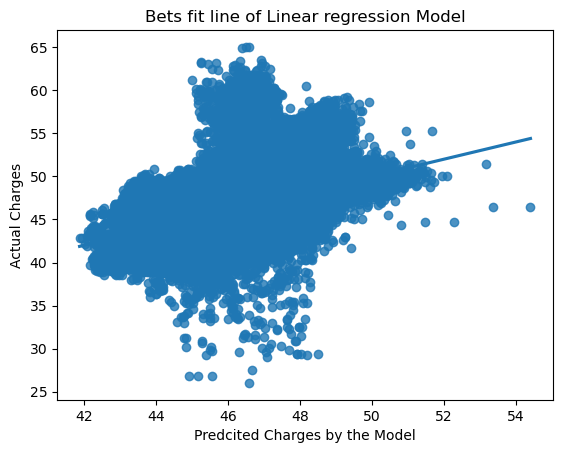

In [67]:
sns.regplot(x=y_pred,y=y_test)
plt.xlabel('Predcited Charges by the Model')
plt.ylabel('Actual Charges')
plt.title('Bets fit line of Linear regression Model')
plt.show()

In [76]:
from sklearn.tree import DecisionTreeRegressor
dt_model = DecisionTreeRegressor(random_state=73)

In [77]:
dt_model.fit(x_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,73
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [78]:
#Test the Model
y_pred_dt=dt_model.predict(x_test)

In [79]:
y_pred_dt

array([48.27224731, 48.84221903, 43.70986938, ..., 47.75188828,
       44.69272423, 46.66859563], shape=(181921,))

In [80]:
mean_squared_error(y_test,y_pred_dt)

0.8162937332160757

In [81]:
r2_score(y_test,y_pred_dt)

0.8804653542292299

In [82]:
rmse_dt = np.sqrt(mean_squared_error(y_test,y_pred_dt))
rmse_dt

np.float64(0.9034897526901319)